# D1-03 Manual LCA with NumPy matrices - Heijungs and Suh 2002 vs Brightway

This notebook reconstructs the matrix-based computation logic behind LCA by hand.
The goal is not to replace `brightway`, but to make its calculation steps transparent on small examples.


## Learning goals

- Distinguish the compact Heijungs and Suh formulation from a stepwise `brightway`-style decomposition.
- Write down `A`, `B`, `f`, and `q` for a small product system.
- Solve `A s = f` with `numpy`.
- Compute inventory and characterized results manually.
- Explain why keeping contribution matrices is useful before moving back to software tools.


## Background references

- Heijungs, R., & Suh, S. (2002). *The computational structure of life cycle assessment*. Kluwer Academic Publishers. https://doi.org/10.1007/978-94-015-9900-9
- Mutel, C. (2017). *Brightway: An open source framework for life cycle assessment*. Journal of Open Source Software, 2(12), 236. https://doi.org/10.21105/joss.00236


## 1) Two equivalent views of the same calculation

In the compact Heijungs and Suh notation, the inventory and characterization steps are usually written as:

$$\mathbf{g} = \mathbf{B}\mathbf{A}^{-1}\mathbf{f}$$

and, for one impact category,

$$h = \mathbf{q}^T \mathbf{g} = \mathbf{q}^T \mathbf{B}\mathbf{A}^{-1}\mathbf{f}$$

If we characterize several impact categories at once, the row vector $\mathbf{q}^T$ becomes a matrix $\mathbf{Q}$ and we write:

$$\mathbf{h} = \mathbf{Q}\mathbf{g} = \mathbf{Q}\mathbf{B}\mathbf{A}^{-1}\mathbf{f}$$

In a `brightway`-style workflow, we often unpack the same logic into smaller steps:

$$\mathbf{A}\mathbf{s} = \mathbf{f}$$
$$\mathbf{G} = \mathbf{B}\,\mathrm{diag}(\mathbf{s})$$
$$\mathbf{H} = \mathrm{diag}(\mathbf{q})\mathbf{G}$$

The total score is the same. The main difference is emphasis:

- Heijungs and Suh highlight the compact algebra and the final aggregation.
- `brightway` often keeps intermediate matrices such as `G` and `H` visible because they are useful for contribution analysis.

So in this notebook, `diag(q)` is not presented as the standard Heijungs and Suh characterization formula. It is a practical way to keep elementary-flow and activity-level contributions visible before summing them up.


## 2) Notation used in this notebook

We use the following notation:

- `A`: technosphere matrix
- `B`: intervention matrix
- `f`: demand vector
- `s`: scaling vector, obtained from `A s = f`
- `g = B s = B A^{-1} f`: aggregated inventory vector
- `q`: characterization-factor vector for one impact category
- `h = q^T g = q^T B A^{-1} f`: aggregated characterized score
- `G = B diag(s)`: inventory results kept in matrix form
- `Q = diag(q)`: diagonal form used only to preserve characterized contributions by elementary flow
- `H = Q G`: characterized inventory matrix, with `h = H 1`

The bridge to `brightway` is that `G` and `H` keep the contribution of each activity visible.


In [1]:
import numpy as np
import pandas as pd 
from IPython.display import display

# this is just to tell Jupyter to keep three decimals after the comma
pd.options.display.float_format = '{:,.3f}'.format


## 3) Example 1: reuse the coal power plant system from `D1-02`

We will now reuse the small system from the previous notebook:

- `Coal power plant` produces electricity.
- `Coal mining` produces coal.
- The power plant needs coal.
- Coal mining needs a small amount of electricity.
- Both activities emit elementary flows to the biosphere.

We keep one impact category only: climate change, with `CO2 = 1` and `CH4 = 28`.


In [2]:
products1 = ['Electricity [kWh]', 'Coal [kg]']
activities1 = ['Coal power plant', 'Coal mining']
flows1 = ['Carbon dioxide, fossil [kg]', 'Methane, fossil [kg]']

A1 = np.array([
    [1.0, -0.025],
    [-0.4, 1.0],              #Input is positive and output is negative
])
B1 = np.array([
    [1.04, 0.3],
    [0.0, 0.05],
])
f1 = np.array([1.0, 0.0])
q1 = np.array([1.0, 28.0])

print('Technosphere matrix A1')
display(pd.DataFrame(A1, index=products1, columns=activities1))

print('Intervention matrix B1')
display(pd.DataFrame(B1, index=flows1, columns=activities1))

print('Demand vector f1')
display(pd.DataFrame(f1, index=products1, columns=["Demand"]))

print('Characterization vector q1')
display(pd.DataFrame(q1, index=flows1, columns=['CF']))


Technosphere matrix A1


,Coal power plant,Coal mining
Electricity [kWh],1.000,-0.025
Coal [kg],-0.400,1.000


Intervention matrix B1


,Coal power plant,Coal mining
"Carbon dioxide, fossil [kg]",1.040,0.300
"Methane, fossil [kg]",0.000,0.050


Demand vector f1


,Demand
Electricity [kWh],1.000
Coal [kg],0.000


Characterization vector q1


,CF
"Carbon dioxide, fossil [kg]",1.000
"Methane, fossil [kg]",28.000


### 3.1) Compact Heijungs and Suh path

We first follow the compact textbook formulation:

$$\mathbf{g} = \mathbf{B}\mathbf{A}^{-1}\mathbf{f}$$
$$h = \mathbf{q}^T \mathbf{g}$$

This route goes directly from the matrices to the aggregated inventory vector `g` and the final scalar score `h`.


In [3]:
A1_inv = np.linalg.inv(A1) # we find the inverse of A
g1_hs = B1 @ A1_inv @ f1 # BA^-1
h1_hs = q1 @ g1_hs #q^Tg

print('Inverse technosphere matrix A1^-1')
display(pd.DataFrame(A1_inv, index=activities1, columns=products1))

print('Aggregated inventory vector g1_hs = B1 @ A1^-1 @ f1')
display(pd.DataFrame(g1_hs, index=flows1, columns=["Elementary flow"]))

print(f'Aggregated characterized score h1_hs = q1^T @ g1_hs: {h1_hs:.2f} kg CO2-eq.')


Inverse technosphere matrix A1^-1


,Electricity [kWh],Coal [kg]
Coal power plant,1.010,0.025
Coal mining,0.404,1.010


Aggregated inventory vector g1_hs = B1 @ A1^-1 @ f1


,Elementary flow
"Carbon dioxide, fossil [kg]",1.172
"Methane, fossil [kg]",0.020


Aggregated characterized score h1_hs = q1^T @ g1_hs: 1.74 kg CO2-eq.


### 3.2) Brightway-style path

Now we unpack the same calculation into smaller steps:

$$\mathbf{A}\mathbf{s} = \mathbf{f}$$
$$\mathbf{g} = \mathbf{B}\mathbf{s}$$
$$\mathbf{G} = \mathbf{B}\,\mathrm{diag}(\mathbf{s})$$
$$\mathbf{H} = \mathrm{diag}(\mathbf{q})\mathbf{G}$$
$$h = \mathbf{H}\mathbf{1}$$

This route reaches the same total, but it preserves process-level and flow-level contributions on the way.


In [4]:
print('Scaling vector s from A1 @ s = f1')
s = np.linalg.solve(A1, f1)
display(pd.DataFrame(s, index=activities1, columns=['scale']))

print('Inventory matrix G = B1 @ diag(s)')
G = B1 @ np.diag(s)
display(pd.DataFrame(G, index=flows1, columns=activities1))

print('Diagonalized characterization matrix Q = diag(q1)')
Q = np.diag(q1)
display(pd.DataFrame(Q, index=flows1, columns=flows1))

print('Characterized inventory matrix H = Q @ G')
H = Q @ G
display(pd.DataFrame(H, index=flows1, columns=activities1))

print(f'Total characterized score H.sum(): {H.sum():.2f} kg CO2-eq.')


Scaling vector s from A1 @ s = f1


,scale
Coal power plant,1.010
Coal mining,0.404


Inventory matrix G = B1 @ diag(s)


,Coal power plant,Coal mining
"Carbon dioxide, fossil [kg]",1.051,0.121
"Methane, fossil [kg]",0.000,0.020


Diagonalized characterization matrix Q = diag(q1)


,"Carbon dioxide, fossil [kg]","Methane, fossil [kg]"
"Carbon dioxide, fossil [kg]",1.000,0.000
"Methane, fossil [kg]",0.000,28.000


Characterized inventory matrix H = Q @ G


,Coal power plant,Coal mining
"Carbon dioxide, fossil [kg]",1.051,0.121
"Methane, fossil [kg]",0.000,0.566


Total characterized score H.sum(): 1.74 kg CO2-eq.


### 3.3) Put the two views side by side

The numerical result is the same, but the intermediate objects do not have the same shape.
That is the key reason why the `brightway`-style decomposition is useful for contribution analysis.


In [5]:
activity_levels_hs = A1_inv @ f1
inventory_from_G = G.sum(axis=1)

parallel = pd.DataFrame(
    [
        ['Technosphere system', 'A1', A1.shape, 'A1', A1.shape],
        ['Demand', 'f1', f1.shape, 'f1', f1.shape],
        ['Activity levels', 'A1^-1 @ f1', activity_levels_hs.shape, 's', s.shape],
        ['Inventory result', 'g1_hs', g1_hs.shape, 'G.sum(axis=1)', inventory_from_G.shape],
        ['Characterization factors', 'q1^T', q1.shape, 'diag(q1)', Q.shape],
        ['Contribution-preserving inventory', 'not kept explicitly', '-', 'G', G.shape],
        ['Contribution-preserving impacts', 'not kept explicitly', '-', 'H', H.shape],
        ['Final characterized result', 'h1_hs', np.shape(h1_hs), 'H.sum()', np.shape(H.sum())],
    ],
    columns=['Stage', 'Heijungs and Suh', 'Shape (HS)', 'Brightway-style', 'Shape (BW)'],
)

display(parallel)

print('Do both routes give the same activity levels?', np.allclose(activity_levels_hs, s))
print('Do both routes give the same inventory vector?', np.allclose(g1_hs, inventory_from_G))
print('Do both routes give the same total score?', np.isclose(h1_hs, H.sum()))


,Stage,Heijungs and Suh,Shape (HS),Brightway-style,Shape (BW)
0,Technosphere system,A1,"(2, 2)",A1,"(2, 2)"
1,Demand,f1,"(2,)",f1,"(2,)"
2,Activity levels,A1^-1 @ f1,"(2,)",s,"(2,)"
3,Inventory result,g1_hs,"(2,)",G.sum(axis=1),"(2,)"
4,Characterization factors,q1^T,"(2,)",diag(q1),"(2, 2)"
5,Contribution-preserving inventory,not kept explicitly,-,G,"(2, 2)"
6,Contribution-preserving impacts,not kept explicitly,-,H,"(2, 2)"
7,Final characterized result,h1_hs,(),H.sum(),()


Do both routes give the same activity levels? True
Do both routes give the same inventory vector? True
Do both routes give the same total score? True


## Checkpoint 1

Change the functional unit so that demand is `2` kWh of electricity.
Recompute `s`, `G`, and the total characterized score.


In [ ]:
# TODO
# f1_new = ...
# s_new = ...
# G_new = ...
# total_score_new = ...


In [ ]:
f1_new = np.array([2.0, 0.0])
s_new = np.linalg.solve(A1, f1_new)
G_new = B1 @ np.diag(s_new)
H_new = Q @ G_new
total_score_new = H_new.sum()

print('New scaling vector s:')
display(pd.DataFrame(s_new, index=activities1, columns=['scale']))

print('New inventory matrix G:')
display(pd.DataFrame(G_new, index=flows1, columns=activities1))

print(f'New total characterized score: {total_score_new:.2f} kg CO2-eq.')


## 4) Example 2: a compact regionalized lithium supply chain

This second system follows a small regionalized supply chain for cathode active material (CAM):

- `Li+ extraction (CL)` produces `1 kg Li+ (aq.)`, requires `0.5 kWh Electricity (CL)`, and withdraws `2 kg Water, underground`.
- `Hydropower (CL)` produces `1 kWh Electricity (CL)` and withdraws `0.02 kg Water, unspecified`.
- `Li2CO3 production (CN)` produces `1 kg Li2CO3`, requires `0.8 kg Li+ (aq.)` and `3 kWh Electricity (CN)`, and withdraws `3 kg Water, surface`.
- `Hydropower (CN)` produces `1 kWh Electricity (CN)` and withdraws `0.015 kg Water, unspecified`.
- `CAM production (DE)` produces `1 kg CAM`, requires `0.1 kg Li+ (aq.)`, `0.2 kg Li2CO3`, `25 kWh Electricity (CL)`, and `25 kWh Electricity (DE)`, and withdraws `0.2 kg Water, unspecified`.
- `Hydropower (DE)` produces `1 kWh Electricity (DE)` and withdraws `0.005 kg Water, unspecified`.

So the chain moves across three regions, and the biosphere matrix keeps track of where water withdrawals occur.


Let's try to graph this (you do not need to pay attention to the code here).

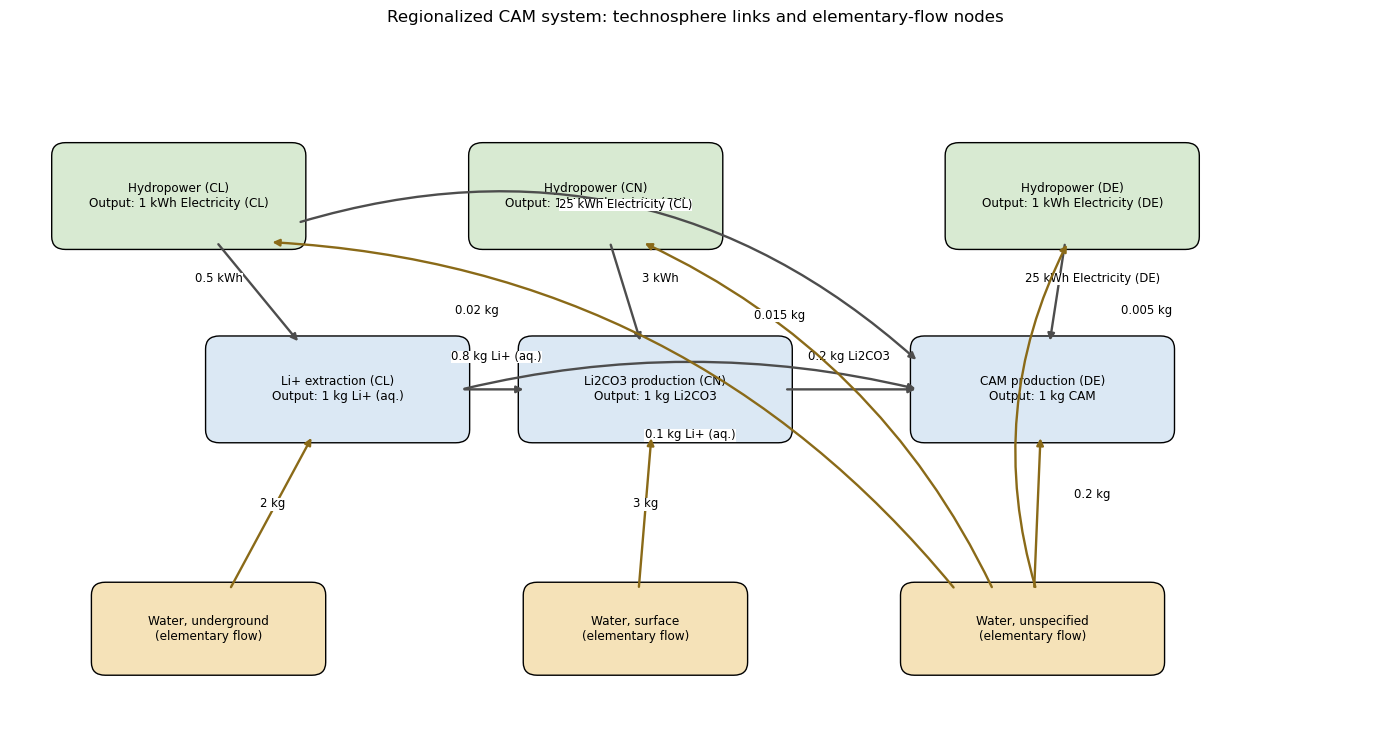

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 7.5))
ax.set_xlim(0, 13.8)
ax.set_ylim(0, 7.6)
ax.axis('off')

nodes = {
    'hydro_cl': {
        'pos': (1.7, 5.8),
        'size': (2.4, 1.0),
        'text': 'Hydropower (CL)\nOutput: 1 kWh Electricity (CL)',
        'color': '#d8ead2',
    },
    'li': {
        'pos': (3.3, 3.7),
        'size': (2.5, 1.0),
        'text': 'Li+ extraction (CL)\nOutput: 1 kg Li+ (aq.)',
        'color': '#dbe8f4',
    },
    'hydro_cn': {
        'pos': (5.9, 5.8),
        'size': (2.4, 1.0),
        'text': 'Hydropower (CN)\nOutput: 1 kWh Electricity (CN)',
        'color': '#d8ead2',
    },
    'li2co3': {
        'pos': (6.5, 3.7),
        'size': (2.6, 1.0),
        'text': 'Li2CO3 production (CN)\nOutput: 1 kg Li2CO3',
        'color': '#dbe8f4',
    },
    'hydro_de': {
        'pos': (10.7, 5.8),
        'size': (2.4, 1.0),
        'text': 'Hydropower (DE)\nOutput: 1 kWh Electricity (DE)',
        'color': '#d8ead2',
    },
    'cam': {
        'pos': (10.4, 3.7),
        'size': (2.5, 1.0),
        'text': 'CAM production (DE)\nOutput: 1 kg CAM',
        'color': '#dbe8f4',
    },
    'water_underground': {
        'pos': (2.0, 1.1),
        'size': (2.2, 0.85),
        'text': 'Water, underground\n(elementary flow)',
        'color': '#f5e2b8',
    },
    'water_surface': {
        'pos': (6.3, 1.1),
        'size': (2.1, 0.85),
        'text': 'Water, surface\n(elementary flow)',
        'color': '#f5e2b8',
    },
    'water_unspecified': {
        'pos': (10.3, 1.1),
        'size': (2.5, 0.85),
        'text': 'Water, unspecified\n(elementary flow)',
        'color': '#f5e2b8',
    },
}

for spec in nodes.values():
    x, y = spec['pos']
    w, h = spec['size']
    patch = FancyBboxPatch(
        (x - w / 2, y - h / 2),
        w,
        h,
        boxstyle='round,pad=0.08,rounding_size=0.14',
        facecolor=spec['color'],
        edgecolor='black',
        linewidth=1.0,
    )
    ax.add_patch(patch)
    ax.text(x, y, spec['text'], ha='center', va='center', fontsize=8.7)


def border_point(node_key, toward_key):
    x0, y0 = nodes[node_key]['pos']
    x1, y1 = nodes[toward_key]['pos']
    w, h = nodes[node_key]['size']
    dx = x1 - x0
    dy = y1 - y0
    if dx == 0 and dy == 0:
        return x0, y0
    scale = max(abs(dx) / (w / 2), abs(dy) / (h / 2))
    return x0 + dx / scale, y0 + dy / scale


def add_edge(start, end, label, *, dx=0.0, dy=0.0, rad=0.0, color='#4d4d4d'):
    start_pt = border_point(start, end)
    end_pt = border_point(end, start)
    ax.annotate(
        '',
        xy=end_pt,
        xytext=start_pt,
        arrowprops={
            'arrowstyle': '-|>',
            'lw': 1.7,
            'color': color,
            'connectionstyle': f'arc3,rad={rad}',
        },
    )
    mx = (nodes[start]['pos'][0] + nodes[end]['pos'][0]) / 2 + dx
    my = (nodes[start]['pos'][1] + nodes[end]['pos'][1]) / 2 + dy
    ax.text(
        mx,
        my,
        label,
        fontsize=8.4,
        ha='center',
        va='center',
        bbox={'fc': 'white', 'ec': 'none', 'pad': 0.2},
    )


# Technosphere links
add_edge('hydro_cl', 'li', '0.5 kWh', dx=-0.4, dy=0.15)
add_edge('li', 'li2co3', '0.8 kg Li+ (aq.)', dy=0.35)
add_edge('hydro_cn', 'li2co3', '3 kWh', dx=0.35, dy=0.15)
add_edge('li', 'cam', '0.1 kg Li+ (aq.)', dy=-0.5, rad=-0.12)
add_edge('li2co3', 'cam', '0.2 kg Li2CO3', dy=0.35)
add_edge('hydro_cl', 'cam', '25 kWh Electricity (CL)', dx=0.15, dy=0.95, rad=-0.28)
add_edge('hydro_de', 'cam', '25 kWh Electricity (DE)', dx=0.35, dy=0.15)

# Elementary-flow nodes
add_edge('water_underground', 'li', '2 kg', dy=0.05, color='#8a6a18')
add_edge('water_surface', 'li2co3', '3 kg', dy=0.05, color='#8a6a18')
add_edge('water_unspecified', 'hydro_cl', '0.02 kg', dx=-1.3, dy=1.1, rad=0.22, color='#8a6a18')
add_edge('water_unspecified', 'hydro_cn', '0.015 kg', dx=-0.35, dy=1.05, rad=0.18, color='#8a6a18')
add_edge('water_unspecified', 'cam', '0.2 kg', dx=0.55, dy=0.15, color='#8a6a18')
add_edge('water_unspecified', 'hydro_de', '0.005 kg', dx=0.95, dy=1.1, rad=-0.2, color='#8a6a18')

ax.set_title('Regionalized CAM system: technosphere links and elementary-flow nodes', fontsize=12)
fig.tight_layout()
plt.show(block=False)
plt.close(fig)


Now, let's build `A` (technosphere matrix), `B` (interventaion matrix), `f` (demand vector) and `Q` (characterization matrix).

In [8]:
products = [
    'Li+ (aq.) [kg]',
    'Electricity (CL) [kWh]',
    'Li2CO3 [kg]',
    'Electricity (CN) [kWh]',
    'CAM [kg]',
    'Electricity (DE) [kWh]',
]
activities = [
    'Li+ extraction (CL)',
    'Hydropower (CL)',
    'Li2CO3 production (CN)',
    'Hydropower (CN)',
    'CAM production (DE)',
    'Hydropower (DE)',
]
flows = ['Water, underground [kg]', 'Water, surface [kg]', 'Water, unspecified [kg]']

# production (outgoing) exchanges are positive and along the diagonal
# technosphere (incoming) exchange are (often) negative and off-diagonal
A = np.array([
    [ 1.0,  0.0, -0.8, 0.0, -0.1, 0.0],
    [-0.5,  1.0,  0.0, 0.0,-25.0, 0.0],
    [ 0.0,  0.0,  1.0, 0.0, -0.2, 0.0],
    [ 0.0,  0.0, -3.0, 1.0,  0.0, 0.0],
    [ 0.0,  0.0,  0.0, 0.0,  1.0, 0.0],
    [ 0.0,  0.0,  0.0, 0.0,-25.0, 1.0],
])

# biosphere exchanges are positive and off-diagonal
B = np.array([
    [2.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 3.0, 0.0, 0.0, 0.0],
    [0.0, 0.02,0.0,0.015,0.2,0.005],
])
f = np.array([0.0, 0.0, 0.0, 0.0, 1.0, 0.0])
q = np.array([39.5, 39.5, 39.5])

print('Technosphere matrix A')
display(pd.DataFrame(A, index=products, columns=activities))

print('Intervention matrix B')
display(pd.DataFrame(B, index=flows, columns=activities))

print('Demand vector f')
display(pd.DataFrame(f, index=products, columns=['Demand']))

print('Characterization vector q')
display(pd.DataFrame(q, index=flows, columns=['CF']))


Technosphere matrix A


,Li+ extraction (CL),Hydropower (CL),Li2CO3 production (CN),Hydropower (CN),CAM production (DE),Hydropower (DE)
Li+ (aq.) [kg],1.000,0.000,-0.800,0.000,-0.100,0.000
Electricity (CL) [kWh],-0.500,1.000,0.000,0.000,-25.000,0.000
Li2CO3 [kg],0.000,0.000,1.000,0.000,-0.200,0.000
Electricity (CN) [kWh],0.000,0.000,-3.000,1.000,0.000,0.000
CAM [kg],0.000,0.000,0.000,0.000,1.000,0.000
Electricity (DE) [kWh],0.000,0.000,0.000,0.000,-25.000,1.000


Intervention matrix B


,Li+ extraction (CL),Hydropower (CL),Li2CO3 production (CN),Hydropower (CN),CAM production (DE),Hydropower (DE)
"Water, underground [kg]",2.000,0.000,0.000,0.000,0.000,0.000
"Water, surface [kg]",0.000,0.000,3.000,0.000,0.000,0.000
"Water, unspecified [kg]",0.000,0.020,0.000,0.015,0.200,0.005


Demand vector f


,Demand
Li+ (aq.) [kg],0.000
Electricity (CL) [kWh],0.000
Li2CO3 [kg],0.000
Electricity (CN) [kWh],0.000
CAM [kg],1.000
Electricity (DE) [kWh],0.000


Characterization vector q


,CF
"Water, underground [kg]",39.500
"Water, surface [kg]",39.500
"Water, unspecified [kg]",39.500


Now, let's compute `s`, `G` and `H`.

In [11]:
s = np.linalg.solve(A, f)
Q = np.diag(q)
G = B @ np.diag(s)
H = Q @ G

print('Scaling vector s')
display(pd.DataFrame(s, index=activities, columns=['Scale']))

print('Diagonalized characterization matrix Q = diag(q)')
display(pd.DataFrame(Q, index=flows, columns=flows))

print('Inventory matrix G = B @ diag(s)')
display(pd.DataFrame(G, index=flows, columns=activities))

print('Characterized inventory matrix H = Q @ G')
display(pd.DataFrame(H, index=flows, columns=activities))

print(f'Total characterized score = H.sum(): {H.sum():.2f}')


Scaling vector s


,Scale
Li+ extraction (CL),0.260
Hydropower (CL),25.130
Li2CO3 production (CN),0.200
Hydropower (CN),0.600
CAM production (DE),1.000
Hydropower (DE),25.000


Diagonalized characterization matrix Q = diag(q)


,"Water, underground [kg]","Water, surface [kg]","Water, unspecified [kg]"
"Water, underground [kg]",39.500,0.000,0.000
"Water, surface [kg]",0.000,39.500,0.000
"Water, unspecified [kg]",0.000,0.000,39.500


Inventory matrix G = B @ diag(s)


,Li+ extraction (CL),Hydropower (CL),Li2CO3 production (CN),Hydropower (CN),CAM production (DE),Hydropower (DE)
"Water, underground [kg]",0.520,0.000,0.000,0.000,0.000,0.000
"Water, surface [kg]",0.000,0.000,0.600,0.000,0.000,0.000
"Water, unspecified [kg]",0.000,0.503,0.000,0.009,0.200,0.125


Characterized inventory matrix H = Q @ G


,Li+ extraction (CL),Hydropower (CL),Li2CO3 production (CN),Hydropower (CN),CAM production (DE),Hydropower (DE)
"Water, underground [kg]",20.540,0.000,0.000,0.000,0.000,0.000
"Water, surface [kg]",0.000,0.000,23.700,0.000,0.000,0.000
"Water, unspecified [kg]",0.000,19.853,0.000,0.356,7.900,4.938


Total characterized score = H.sum(): 77.29


## Why keep `G` and `H` in matrix form?

If we collapse directly to a single total, we lose the activity-by-activity structure.
Keeping `G` and `H` in matrix form makes it easy to see which activity contributes to which flow and which characterized result.

That is the main difference with the approach of Heijungs and Suh (2002) and it is conceptual bridge to the contribution analysis work later in Day 1.


## Checkpoint 2

Using `H`, identify the process with the largest contribution to the total characterized result.
Then identify which elementary flow dominates the total score.


In [ ]:
# TODO
# column_contrib = ...
# row_contrib = ...


In [10]:
column_contrib = pd.DataFrame(H, index=flows, columns=activities).sum(axis=0).sort_values(ascending=False)
row_contrib = pd.DataFrame(H, index=flows, columns=activities).sum(axis=1).sort_values(ascending=False)

print('Activity contributions to the total characterized score:')
display(column_contrib)

print('Elementary-flow contributions to the total characterized score:')
display(row_contrib)

print('Largest contributing activity:', column_contrib.index[0])
print('Dominant elementary flow:', row_contrib.index[0])


Activity contributions to the total characterized score:


Li2CO3 production (CN)   23.700
Li+ extraction (CL)      20.540
Hydropower (CL)          19.853
CAM production (DE)       7.900
Hydropower (DE)           4.938
Hydropower (CN)           0.356
dtype: float64

Elementary-flow contributions to the total characterized score:


Water, unspecified [kg]   33.046
Water, surface [kg]       23.700
Water, underground [kg]   20.540
dtype: float64

Largest contributing activity: Li2CO3 production (CN)
Dominant elementary flow: Water, unspecified [kg]


## 5) Bridge to `brightway`

The manual workflow above is the conceptual foundation for `brightway` calculations:

- activities and exchanges define `A` and `B`
- the demand dictionary defines `f`
- solving the system gives the scaling vector `s`
- characterization factors define `q` or `Q`
- preserving matrix structure supports contribution analysis

In `D1-04`, we stop constructing these objects by hand and let `brightway` build them from imported data.


## Recap

After this notebook, you should now be able to:

- explain the difference between the compact Heijungs and Suh formula and a contribution-preserving `brightway`-style decomposition
- write down the main LCA matrices and vectors
- solve `A s = f` with `numpy`
- compute inventory and characterized results manually
- explain why preserving matrix form is useful
- connect the manual matrix workflow to the software workflow in `brightway`
